<a href="https://colab.research.google.com/github/it0770e/xai-ids/blob/main/Notebook08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CELL 1
from google.colab import drive
drive.mount('/content/drive')
import numpy as np, pandas as pd, joblib, matplotlib.pyplot as plt, warnings
from sklearn.metrics import f1_score, accuracy_score
warnings.filterwarnings('ignore')
np.random.seed(42)
BASE = '/content/drive/MyDrive/xai-ids'
print('✅ Setup complete')

Mounted at /content/drive
✅ Setup complete


In [2]:
# CELL 2
data   = joblib.load(f'{BASE}/data/processed/nsl_kdd_processed.pkl')
X_test = data['X_test']; y_test = data['y_test']
models = {
    'Random Forest': joblib.load(f'{BASE}/results/models/random_forest.pkl'),
    'SVM (RBF)':     joblib.load(f'{BASE}/results/models/svm.pkl'),
    'Naive Bayes':   joblib.load(f'{BASE}/results/models/naive_bayes.pkl'),
    'KNN':           joblib.load(f'{BASE}/results/models/knn.pkl'),
}
print(f'✅ {len(models)} models loaded | test set: {X_test.shape[0]:,} samples')

✅ 4 models loaded | test set: 22,544 samples


In [3]:
# CELL 3 — Bootstrap CI (actually runs)
def bootstrap_ci(y_true, y_pred, n=1000):
    scores = []
    N = len(y_true)
    for _ in range(n):
        idx = np.random.choice(N, N, replace=True)
        scores.append(f1_score(y_true[idx], y_pred[idx], average='macro', zero_division=0))
    return np.percentile(scores,[2.5,97.5]), np.array(scores)

print('Running 1000-iteration bootstrap for each model (~30s)...\n')
ci_results  = {}
predictions = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    f1 = f1_score(y_test, y_pred, average='macro')
    (lo, hi), scores = bootstrap_ci(y_test, y_pred)
    ci_results[name] = {'f1':f1,'lower':lo,'upper':hi,'scores':scores}
    print(f'{name:20s}: F1={f1:.4f}  95% CI: [{lo:.4f}–{hi:.4f}]')

print('\n✅ Bootstrap CIs computed')

Running 1000-iteration bootstrap for each model (~30s)...

Random Forest       : F1=0.7685  95% CI: [0.7634–0.7739]
SVM (RBF)           : F1=0.7813  95% CI: [0.7759–0.7864]
Naive Bayes         : F1=0.7717  95% CI: [0.7665–0.7773]
KNN                 : F1=0.7640  95% CI: [0.7584–0.7695]

✅ Bootstrap CIs computed


In [4]:
# CELL 4 — McNemar's test
from scipy.stats import chi2 as chi2_dist

def mcnemar(y_true, pa, pb):
    b = np.sum((pa==y_true) & (pb!=y_true))
    c = np.sum((pa!=y_true) & (pb==y_true))
    if b+c == 0: return 1.0
    stat = (abs(b-c)-1)**2 / (b+c)
    return 1 - chi2_dist.cdf(stat, df=1)

names = list(models.keys())
print("McNemar's Pairwise Tests (p<0.05 = significantly different)")
print('='*70)
mcnemar_results = []
for i in range(len(names)):
    for j in range(i+1, len(names)):
        a, b = names[i], names[j]
        p = mcnemar(y_test, predictions[a], predictions[b])
        sig = '✅ Significant' if p < 0.05 else '❌ Not significant'
        print(f'{a:20s} vs {b:20s}: p={p:.4f}  {sig}')
        mcnemar_results.append({'model_a':a,'model_b':b,'p_value':round(p,4),'significant':p<0.05})

McNemar's Pairwise Tests (p<0.05 = significantly different)
Random Forest        vs SVM (RBF)           : p=0.0000  ✅ Significant
Random Forest        vs Naive Bayes         : p=0.3814  ❌ Not significant
Random Forest        vs KNN                 : p=0.0158  ✅ Significant
SVM (RBF)            vs Naive Bayes         : p=0.0000  ✅ Significant
SVM (RBF)            vs KNN                 : p=0.0000  ✅ Significant
Naive Bayes          vs KNN                 : p=0.0086  ✅ Significant


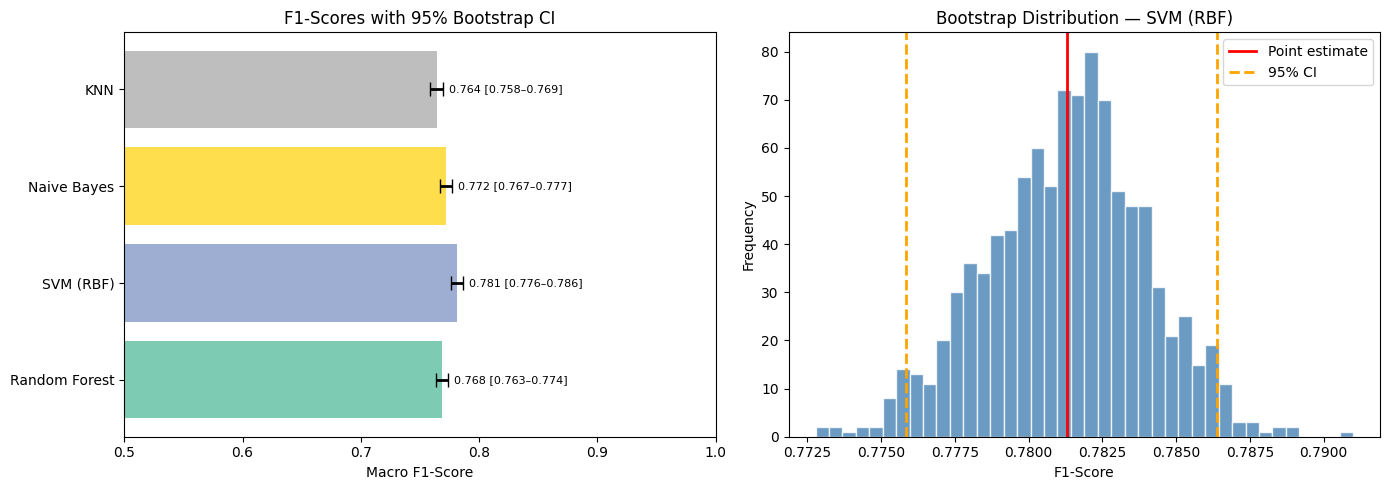

✅ Figure saved


In [5]:
# CELL 5 — Visualise CIs
import pandas as pd
bc    = pd.DataFrame([{'model':n,'f1':v['f1'],'ci_lower':v['lower'],'ci_upper':v['upper']} for n,v in ci_results.items()])
best  = max(ci_results, key=lambda n: ci_results[n]['f1'])

fig, axes = plt.subplots(1,2,figsize=(14,5))
errs = [[r['f1']-r['ci_lower'] for _,r in bc.iterrows()],
        [r['ci_upper']-r['f1'] for _,r in bc.iterrows()]]
axes[0].barh(bc['model'], bc['f1'], xerr=errs, capsize=5,
             color=plt.cm.Set2(np.linspace(0,1,len(bc))), alpha=0.85, error_kw={'linewidth':2})
axes[0].set_xlabel('Macro F1-Score'); axes[0].set_title('F1-Scores with 95% Bootstrap CI'); axes[0].set_xlim(0.5,1.0)
for _, row in bc.iterrows():
    axes[0].text(row['ci_upper']+0.005, list(bc['model']).index(row['model']),
                 f"{row['f1']:.3f} [{row['ci_lower']:.3f}–{row['ci_upper']:.3f}]", va='center', fontsize=8)

bs = ci_results[best]['scores']
axes[1].hist(bs, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(ci_results[best]['f1'],    color='red',    linestyle='-',  linewidth=2, label='Point estimate')
axes[1].axvline(ci_results[best]['lower'], color='orange', linestyle='--', linewidth=2, label='95% CI')
axes[1].axvline(ci_results[best]['upper'], color='orange', linestyle='--', linewidth=2)
axes[1].set_xlabel('F1-Score'); axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Bootstrap Distribution — {best}'); axes[1].legend()

plt.tight_layout()
plt.savefig(f'{BASE}/results/figures/bootstrap_ci.png', dpi=300, bbox_inches='tight')
plt.show(); print('✅ Figure saved')

In [6]:
# CELL 6 — Save
bc.to_csv(f'{BASE}/results/metrics/bootstrap_ci.csv', index=False)
pd.DataFrame(mcnemar_results).to_csv(f'{BASE}/results/metrics/mcnemar_tests.csv', index=False)
print('✅ Statistical results saved')
sig_count = sum(r['significant'] for r in mcnemar_results)
print(f'Significant pairwise differences: {sig_count}/{len(mcnemar_results)}')

✅ Statistical results saved
Significant pairwise differences: 5/6
